In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x_min = -2
x_max = 1
y_min = -1.5
y_max = 1.5
n = 1000
k = 100
cplx = -0.7 + 0.27015j

In [15]:
def mandelbrot_set(x_min, x_max, y_min, y_max, n, k):

    y, x = np.mgrid[y_min: y_max: n * 1j, x_min: x_max: n * 1j]

    c = x + 1j*y

    Z = np.zeros_like(c)

    divergence_matrix = np.zeros(c.shape, dtype=int)

    i = np.ones(c.shape, dtype=bool)

    for a in range(k):
        Z[i] = Z[i]**2 + c[i]

        divergence = np.abs(Z) > 2

        divergence_matrix[i & divergence] = a

        i = i & (~divergence)

    divergence_matrix[i] = k

    return divergence_matrix

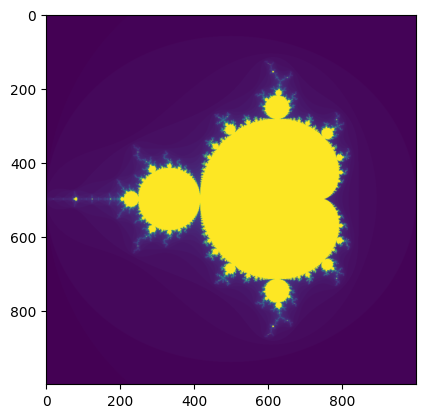

In [16]:
divergence_matrix = mandelbrot_set(x_min, x_max, y_min, y_max, n, k)
plt.imshow(divergence_matrix)

In [35]:
def julia_set(x_min, x_max, y_min, y_max, n, k, cplx):
    
    a = (x_max - x_min)/8
    b = (y_max - y_min)/8
    
    x_min = x_min - a
    y_min = y_min - b
    x_max = x_max + a
    y_max = y_max + b

    y, x = np.mgrid[y_min: y_max: n * 1j, x_min: x_max: n * 1j]

    Z = x + 1j * y

    cplx = np.full(Z.shape, cplx, dtype=complex)

    divergence_matrix = np.zeros(Z.shape, dtype=int)

    i = np.ones(Z.shape, dtype=bool)

    for a in range(k):

        Z[i] = Z[i]**2 + cplx[i]

        divergence = np.abs(Z) > 2

        divergence_matrix[i & divergence] = a

        i = i & (~divergence)

    divergence_matrix[i] = k

    return divergence_matrix

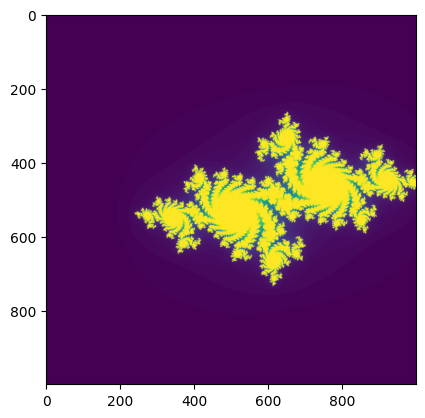

In [36]:
divergence_matrix = julia_set(x_min, x_max, y_min, y_max, n, k, cplx)
plt.imshow(divergence_matrix)